# IMDb sentiment analízis BERT-tel Colabban

Ez a notebook a feltöltött **`IMDB_Dataset.csv`** állományból indul ki, majd:

1. beolvassa az IMDb adatbázist,
2. előfeldolgozza a címkéket,
3. tanító / validációs / teszt halmazt készít,
4. finomhangol egy **BERT** modellt bináris szentimentelemzésre,
5. lefuttatja az előrejelzéseket a teszthalmazon,
6. **összehasonlítja a BERT által adott pozitív/negatív besorolást az IMDb eredeti címkéivel**,
7. kiszámítja a fő értékelési mutatókat és ábrázolja a keveredési mátrixot.

> Megjegyzés: ez a notebook **felügyelt tanulást** használ. Vagyis a BERT-modellt az IMDb címkézett adathalmazán tanítjuk, majd a teszthalmazon összevetjük a modell predikcióit az eredeti IMDb-címkékkel.

## 1. Környezet előkészítése

Ez a blokk telepíti a szükséges könyvtárakat Colab környezetben.

In [ ]:
!pip -q install transformers datasets accelerate evaluate scikit-learn pandas numpy matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.4 MB/s eta 0:00:00


## 2. Könyvtárak importálása és reprodukálhatóság

Itt minden fontos csomagot importálunk, valamint rögzítjük a random seed értékét.

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

import torch
from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print("PyTorch verzió:", torch.__version__)
print("GPU elérhető:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU neve:", torch.cuda.get_device_name(0))

PyTorch verzió: 2.10.0+cu128
GPU elérhető: True
GPU neve: Tesla T4


## 3. A fájl beolvasása

A notebook alapértelmezetten a feltöltött **`IMDB_Dataset.csv`** fájlt várja.
Ha más útvonalon van a fájl, elég a `CSV_PATH` változót módosítani.

In [ ]:
# # Alapértelmezett fájlnév
# #CSV_PATH = "/content/IMDB_Dataset.csv"

# # Ha Google Drive-ból dolgozunk, például így adhatjuk meg:
# # CSV_PATH = "/content/drive/MyDrive/IMDB_Dataset.csv"

# if not os.path.exists(CSV_PATH):
#     raise FileNotFoundError(
#         f"A fájl nem található itt: {CSV_PATH}\n"
#         "Töltsd fel a Colab munkakönyvtárba, vagy módosítsd a CSV_PATH változót."
#     )

# df = pd.read_csv(CSV_PATH)
# print("Adathalmaz alakja:", df.shape)
# display(df.head())

In [ ]:
# ============================================================
# IMDb dataset betöltése HuggingFace mirrorból
# ============================================================

import pandas as pd

CSV_PATH = "hf://datasets/Q-b1t/IMDB-Dataset-of-50K-Movie-Reviews-Backup/archive.zip"

df = pd.read_csv(CSV_PATH, compression="zip")

print("Dataset shape:", df.shape)
df.head()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Dataset shape: (50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df.describe()

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


## 4. Az adathalmaz gyors ellenőrzése

Ebben a blokkban megnézzük az oszlopokat, az esetleges hiányzó értékeket és az osztályeloszlást.

Oszlopok: ['review', 'sentiment']

Hiányzó értékek:
review       0
sentiment    0
dtype: int64

Címkék eloszlása:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


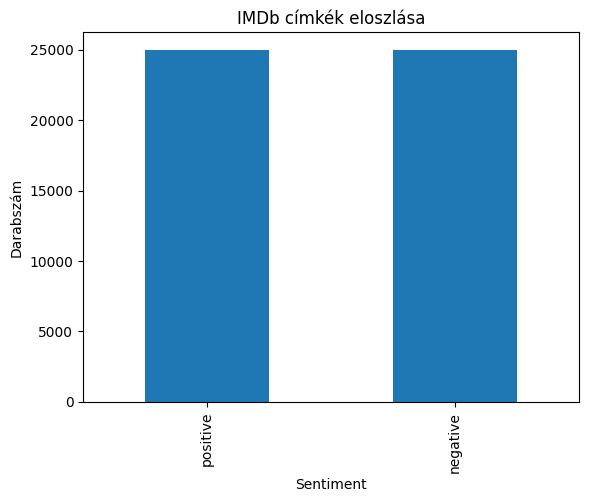

In [ ]:
print("Oszlopok:", df.columns.tolist())
print("\nHiányzó értékek:")
print(df.isna().sum())

print("\nCímkék eloszlása:")
print(df["sentiment"].value_counts())

ax = df["sentiment"].value_counts().plot(kind="bar", title="IMDb címkék eloszlása")
ax.set_xlabel("Sentiment")
ax.set_ylabel("Darabszám")
plt.show()

## 5. Címkék kódolása és opcionális mintavétel

A `sentiment` oszlop szöveges címkéit numerikus formára alakítjuk:

- `negative` → 0
- `positive` → 1

A teljes IMDb adatbázis 50 000 rekordot tartalmaz.  
Gyors teszteléshez beállítható kisebb minta is. Ha teljes tanítást szeretnél, hagyd a `USE_SUBSET = False` értéket.

In [ ]:
label_map = {"negative": 0, "positive": 1}

df = df.dropna(subset=["review", "sentiment"]).copy()
df["label"] = df["sentiment"].map(label_map)

if df["label"].isna().any():
    bad_values = df.loc[df["label"].isna(), "sentiment"].unique()
    raise ValueError(f"Ismeretlen címke található: {bad_values}")

# -------- Gyors teszthez kisebb minta --------
USE_SUBSET = True
SUBSET_SIZE = 12000   # például 12000 rekord gyorsabb Colab futáshoz

if USE_SUBSET:
    df = (
        df.groupby("label", group_keys=False)
          .apply(lambda x: x.sample(n=min(len(x), SUBSET_SIZE // 2), random_state=SEED))
          .sample(frac=1, random_state=SEED)
          .reset_index(drop=True)
    )

print("Felhasznált adatmennyiség:", df.shape)
print(df["label"].value_counts())
display(df.head())

Felhasznált adatmennyiség: (12000, 3)
label
0    6000
1    6000
Name: count, dtype: int64


/tmp/ipykernel_403/2090711760.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(len(x), SUBSET_SIZE // 2), random_state=SEED))


,review,sentiment,label
0,Fame did something odd. It was not only a musi...,negative,0
1,Claudine is a movie that is representation of ...,positive,1
2,It is fitting that the title character in Sydn...,negative,0
3,In this glorious telling of a weekend shared a...,positive,1
4,"Reeves plays Haji Murad, a hero in 1850's Russ...",negative,0


## 6. Tanító / validációs / teszt halmaz létrehozása

A cél az, hogy a modell teljesítményét olyan adatokon mérjük, amelyeket a tanítás során nem látott.  
Ezért három részre bontjuk az állományt:

- **train**: tanítás
- **validation**: hangolás / ellenőrzés
- **test**: végső összehasonlítás az IMDb eredeti címkéivel

In [ ]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["label"],
    random_state=SEED
)

valid_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

print("Train:", train_df.shape)
print("Validation:", valid_df.shape)
print("Test:", test_df.shape)

dataset = DatasetDict({
    "train": Dataset.from_pandas(train_df[["review", "label"]].reset_index(drop=True)),
    "validation": Dataset.from_pandas(valid_df[["review", "label"]].reset_index(drop=True)),
    "test": Dataset.from_pandas(test_df[["review", "label"]].reset_index(drop=True)),
})

dataset

Train: (9600, 3)
Validation: (1200, 3)
Test: (1200, 3)


DatasetDict({
    train: Dataset({
        features: ['review', 'label'],
        num_rows: 9600
    })
    validation: Dataset({
        features: ['review', 'label'],
        num_rows: 1200
    })
    test: Dataset({
        features: ['review', 'label'],
        num_rows: 1200
    })
})

## 7. Tokenizálás

A BERT szöveget nem közvetlenül, hanem tokenek formájában dolgozza fel.  
Ehhez a **`bert-base-uncased`** tokenizálót használjuk.

> Mivel az IMDb angol nyelvű, az angol BERT-modell megfelelő választás.

In [ ]:
MODEL_NAME = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(examples):
    return tokenizer(
        examples["review"],
        truncation=True,
        max_length=256
    )

tokenized_dataset = dataset.map(tokenize_function, batched=True)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

tokenized_dataset

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/9600 [00:00<?, ? examples/s]

Map:   0%|          | 0/1200 [00:00<?, ? examples/s]

Map:   0%|          | 0/1200 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['review', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 9600
    })
    validation: Dataset({
        features: ['review', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1200
    })
    test: Dataset({
        features: ['review', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1200
    })
})

## 8. Értékelési függvény

Ez a blokk számolja ki a fő metrikákat:

- accuracy
- precision
- recall
- F1

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary", zero_division=0
    )
    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

## 9. A BERT modell betöltése

A modell bináris osztályozásra lesz finomhangolva (`num_labels=2`).

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## 10. Tanítási paraméterek

Itt adhatod meg a tanítás fő beállításait.  
Colab GPU-n tipikusan működőképes kezdőbeállítások szerepelnek.

Ha memóriahiba jelentkezik:
- csökkentsd a `per_device_train_batch_size` értékét,
- vagy csökkentsd a `max_length` értékét a tokenizálásnál,
- vagy dolgozz kisebb mintán.

In [ ]:
# ============================================================
# BERT finomhangolás (fine-tuning) beállításai
# ============================================================

# A TrainingArguments objektum tartalmazza a tanítás minden
# fontos hiperparaméterét és működési beállítását.

training_args = TrainingArguments(

    # Ide kerülnek a tanítás során mentett modellek és logok
    output_dir="./bert_imdb_results",

    # Minden epoch végén történik kiértékelés a validációs adaton
    eval_strategy="epoch",

    # Minden epoch végén mentünk egy modell checkpointot
    save_strategy="epoch",

    # A tanítás során bizonyos lépések után logolunk
    logging_strategy="steps",

    # 100 tanítási lépésenként ír ki státusz információkat
    logging_steps=100,

    # Tanulási ráta (learning rate)
    # BERT finomhangolásnál tipikus érték 1e-5 – 5e-5 között
    learning_rate=2e-5,

    # Batch méret tanításkor (egy GPU-n egyszerre feldolgozott minták)
    per_device_train_batch_size=8,

    # Batch méret kiértékeléskor
    per_device_eval_batch_size=16,

    # Tanítási epochok száma
    # Egy epoch = a teljes tanítóadat egyszeri feldolgozása
    num_train_epochs=2,

    # Súlycsökkentés (regularizáció) a túlillesztés csökkentésére
    weight_decay=0.01,

    # A tanítás végén a validáció alapján legjobb modellt tölti vissza
    load_best_model_at_end=True,

    # A modell kiválasztásának alapja az F1 mutató
    metric_for_best_model="f1",

    # Mivel F1 esetén a nagyobb érték a jobb
    greater_is_better=True,

    # Maximum 2 checkpointot tart meg (tárhely optimalizálás)
    save_total_limit=2,

    # Nem küld logokat külső monitoring rendszerekbe (pl. WandB)
    report_to="none",

    # Ha GPU elérhető, használjon 16 bites lebegőpontos számolást
    # Ez gyorsabb és kevesebb memóriát használ
    fp16=torch.cuda.is_available()
)


# ============================================================
# Trainer objektum létrehozása
# ============================================================

# A Trainer a HuggingFace magas szintű tanító API-ja,
# amely automatizálja a tanítást, validációt és logolást.

trainer = Trainer(

    # A tanítandó modell (BERT Sequence Classification)
    model=model,

    # A tanítás paraméterei
    args=training_args,

    # Tanító adathalmaz (tokenizált formában)
    train_dataset=tokenized_dataset["train"],

    # Validációs adathalmaz
    eval_dataset=tokenized_dataset["validation"],

    # A tokenizer (új API-ban processing_class néven)
    processing_class=tokenizer,

    # Batch összeállítási mechanizmus (padding stb.)
    data_collator=data_collator,

    # Egyedi metrika számító függvény
    # (accuracy, precision, recall, f1 stb.)
    compute_metrics=compute_metrics
)


# A trainer objektum megjelenítése (nem indítja el a tanítást)
trainer

## 11. A modell tanítása


In [ ]:
train_result = trainer.train()
train_result

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.303491,0.271718,0.896667,0.851032,0.961667,0.902973
2,0.158848,0.372554,0.905000,0.884494,0.931667,0.907468


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=2400, training_loss=0.25832485675811767, metrics={'train_runtime': 372.3218, 'train_samples_per_second': 51.568, 'train_steps_per_second': 6.446, 'total_flos': 2523243243122880.0, 'train_loss': 0.25832485675811767, 'epoch': 2.0})

## 12. Kiértékelés a validációs halmazon

A validációs eredmények segítségével ellenőrizhetjük, hogy a modell tanulása megfelelő-e.

In [ ]:
val_metrics = trainer.evaluate(tokenized_dataset["validation"])
print("Validációs metrikák:")
for k, v in val_metrics.items():
    print(f"{k}: {v}")

Validációs metrikák:
eval_loss: 0.3725541830062866
eval_accuracy: 0.905
eval_precision: 0.884493670886076
eval_recall: 0.9316666666666666
eval_f1: 0.9074675324675324
eval_runtime: 5.1105
eval_samples_per_second: 234.812
eval_steps_per_second: 14.676
epoch: 2.0


## 13. Végső teszt: BERT predikciók összehasonlítása az IMDb eredeti címkéivel

Ez a notebook kulcsblokkja:  
a **teszthalmazon** előállítjuk a BERT predikcióit, majd ezeket **összevetjük az IMDb adatbázis eredeti pozitív/negatív címkéivel**.

In [ ]:
test_predictions = trainer.predict(tokenized_dataset["test"])

test_logits = test_predictions.predictions
y_true = test_predictions.label_ids
y_pred = np.argmax(test_logits, axis=-1)

label_names = {0: "negative", 1: "positive"}

results_df = test_df[["review", "sentiment", "label"]].reset_index(drop=True).copy()
results_df["bert_pred_label"] = y_pred
results_df["bert_pred_sentiment"] = results_df["bert_pred_label"].map(label_names)
results_df["correct_prediction"] = (results_df["label"] == results_df["bert_pred_label"]).astype(int)

display(results_df.head(10))

,review,sentiment,label,bert_pred_label,bert_pred_sentiment,correct_prediction
0,Taken the idea out of a true diplomatic incide...,positive,1,1,positive,1
1,Franco films can be divided into 4 categories-...,negative,0,0,negative,1
2,I went to see this thinking it would be a grea...,positive,1,1,positive,1
3,Movies like this give independent films a bad ...,negative,0,0,negative,1
4,I must preface this comment with a sort of adm...,negative,0,0,negative,1
5,"I've seen a lot of Seagal movies, and while mo...",negative,0,0,negative,1
6,It is always great to see a movie that teaches...,positive,1,0,negative,0
7,I've been a classic horror fan my entire life....,negative,0,1,positive,0
8,"Indian Directors have it tough, They have to c...",positive,1,0,negative,0
9,I've seen this movie more than once. It isn't ...,positive,1,1,positive,1


## 14. Összesített teljesítménymutatók a teszthalmazon

Itt számoljuk ki a végső összehasonlító mutatókat az IMDb eredeti címkéihez képest.

In [ ]:
test_accuracy = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average="binary", zero_division=0
)

print("TESZT EREDMÉNYEK")
print("-" * 50)
print(f"Accuracy : {test_accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

print("\nOsztályozási riport:")
print(classification_report(
    y_true, y_pred,
    target_names=["negative", "positive"],
    digits=4,
    zero_division=0
))

TESZT EREDMÉNYEK
--------------------------------------------------
Accuracy : 0.9050
Precision: 0.8869
Recall   : 0.9283
F1-score : 0.9072

Osztályozási riport:
              precision    recall  f1-score   support

    negative     0.9248    0.8817    0.9027       600
    positive     0.8869    0.9283    0.9072       600

    accuracy                         0.9050      1200
   macro avg     0.9059    0.9050    0.9049      1200
weighted avg     0.9059    0.9050    0.9049      1200



## 15. Keveredési mátrix

A keveredési mátrix megmutatja, hogy a modell hány negatív és pozitív példát sorolt be helyesen vagy tévesen.

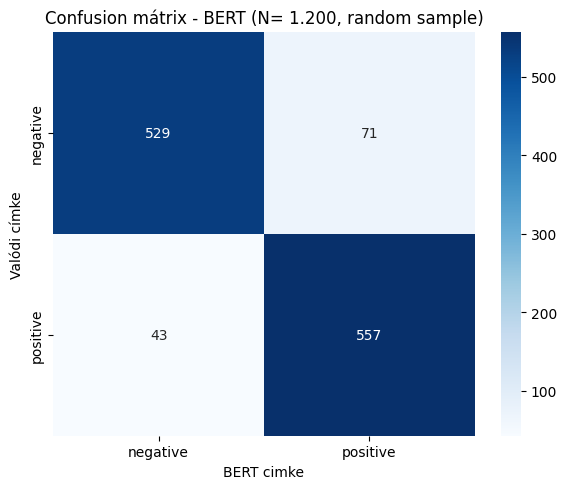

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["negative", "positive"],
    yticklabels=["negative", "positive"]
)
plt.title("Confusion mátrix - BERT (N= 1.200, random sample)")
plt.xlabel("BERT cimke")
plt.ylabel("Valódi címke")
plt.tight_layout()
plt.show()

## 16. Téves besorolások megtekintése

A hibás esetek kvalitatív ellenőrzése különösen hasznos az értelmezéshez.

In [ ]:
errors_df = results_df[results_df["correct_prediction"] == 0].copy()

print("Téves besorolások száma:", len(errors_df))
display(
    errors_df[["review", "sentiment", "bert_pred_sentiment"]]
    .head(20)
)

Téves besorolások száma: 114


,review,sentiment,bert_pred_sentiment
6,It is always great to see a movie that teaches...,positive,negative
7,I've been a classic horror fan my entire life....,negative,positive
8,"Indian Directors have it tough, They have to c...",positive,negative
44,I kind of liked The Lonely Lady. Give Pia a br...,positive,negative
73,"I must, in light of the encomia of praise for ...",negative,positive
86,I'm the type of guy who loves hood movies from...,negative,positive
100,The story is similar to ET: an extraterrestria...,negative,positive
110,"This movie is truly amazing,over the years I h...",negative,positive
114,There are lots of extremely good-looking peopl...,negative,positive
149,"Black Rain is a superb film, but watch out for...",positive,negative


## 17. Eredmények mentése CSV-be

Ez a blokk elmenti az egyedi predikciókat, hogy később SPSS-ben, Pythonban vagy Excelben tovább elemezhető.

In [ ]:
# CSV fájl mentési helye a Google Drive-ban
OUTPUT_CSV = "/content/drive/MyDrive/Privat/Study/PE/SZD/IMDb_BERT/bert_imdb_test_predictions.csv"

# Predikciók mentése CSV-be
results_df.to_csv(OUTPUT_CSV, index=False, encoding="utf-8")

print(f"Eredmények elmentve ide: {OUTPUT_CSV}")

Eredmények elmentve ide: /content/drive/MyDrive/Privat/Study/PE/SZD/IMDb_BERT/bert_imdb_test_predictions.csv


## 18. Modell mentése

A finomhangolt modellt és a tokenizálót külön is elmentjük, hogy később újrahasznosítható legyen.

In [ ]:
SAVE_DIR = "/content/bert_imdb_finetuned_model"

trainer.save_model(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

print(f"Modell mentve ide: {SAVE_DIR}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Modell mentve ide: /content/bert_imdb_finetuned_model


## 19. Egyedi szövegek osztályozása a finomhangolt modellel

Ebben a blokkban saját filmszövegekkel vagy review-kal is kipróbálható.

In [ ]:
def predict_sentiment(texts):
    if isinstance(texts, str):
        texts = [texts]

    encodings = tokenizer(
        texts,
        truncation=True,
        padding=True,
        max_length=256,
        return_tensors="pt"
    )

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    encodings = {k: v.to(device) for k, v in encodings.items()}

    model.eval()
    with torch.no_grad():
        outputs = model(**encodings)
        probs = torch.softmax(outputs.logits, dim=-1).cpu().numpy()
        preds = probs.argmax(axis=1)

    out = pd.DataFrame({
        "text": texts,
        "pred_label_num": preds,
        "pred_label": [label_names[p] for p in preds],
        "prob_negative": probs[:, 0],
        "prob_positive": probs[:, 1]
    })
    return out

sample_texts = [
    "This movie was absolutely fantastic, touching and beautifully acted.",
    "I regret watching this film. It was boring, slow and disappointing."
]

display(predict_sentiment(sample_texts))

,text,pred_label_num,pred_label,prob_negative,prob_positive
0,"This movie was absolutely fantastic, touching ...",1,positive,0.001717,0.998283
1,"I regret watching this film. It was boring, sl...",0,negative,0.998966,0.001034


## 20. Rövid értelmezési útmutató

A notebook végén az alábbi logika szerint értelmezhetők az eredmények:

- Ha az **accuracy** és az **F1-score** magas, akkor a BERT jól reprodukálja az IMDb pozitív/negatív címkéit.
- A **confusion matrix** megmutatja, hogy a tévedések inkább a pozitív vagy a negatív osztályban jelentkeznek.
- A **tévesen besorolt példák** segíthetnek feltárni, hogy az irónia, a hosszú review, a vegyes érzelmi tónus vagy a szarkazmus okozza-e a hibákat.

Ezt úgy is megfogalmazható, hogy a finomhangolt BERT-modell teljesítményét az IMDb eredeti annotációihoz viszonyítva validáltuk, és a predikciók pontosságát standard osztályozási metrikákkal értékeltük.